### In this lab you will be running calculations to calculate temporal statistics for drought in the Colorado River Basin

###### Refer to the Lab 6 document posted on canvas. This notebook serves as a code template for your reference

In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [2]:
drought = pd.read_csv('drought.csv')

### 6.1 Calculate Anomalies Per Year

$$ y = y_i - \bar{y}$$

In [3]:
drought.head()

,Year,Mean Annual Temp (deg C),Total Annual Precip (mm),Natural Inflow (bcm)
0,1906,10.4,579.1,23.1
1,1907,10.6,428.2,25.9
2,1908,9.0,460.8,14.4
3,1909,9.2,468.9,27.0
4,1910,10.4,327.7,18.0


In [4]:
drought.columns = ['Year','Temp','Precip','Inflow']

In [57]:
drought_sub = drought[drought['Year'] < 2000]
temp_2000 = np.mean(drought_sub['Temp'])
precip_2000 = #Fill in
inflow_2000 = #Fill in

In [58]:
anomaly_temp = #Fill in
anomaly_precip = #Fill in
anomaly_inflow = #Fill in

In [59]:
drought['Temp_A'] = #fill in
drought['Precip_A'] = #fill in
drought['Inflow_A'] = #fill in

### Create scatterplots (2c)

In [ ]:
plt.figure(figsize=(10, 6))
# Method 1: Scatter plot
plt.scatter(drought['Temp_A'], drought['Inflow_A'], alpha=0.5)

# Method 2: Line plot (if ordered)
# plt.plot(df['15Y_Inflow'], df['Pred_Inflow'])

plt.xlabel('Inflow')
plt.ylabel('Temp')
plt.title('Inflow vs Temp')
plt.grid(True)
plt.show()

In [ ]:
### Repeat for Precip

### 6.2 Calculate Statistics by Year

In [60]:
c1 = drought[(drought['Year'] >= ) & (drought['Year'] <= )]
c1_temp_mean = #fill in
c1_inflow_mean = #fill in
c1_precip_mean = #fill in

In [74]:
c1_pct_inflow = (c1_inflow_mean/inflow_2000)*100
c1_temp_anom2000 = (c1_temp_mean-temp_2000)
c1_pct_precip = ((c1_precip_mean-precip_2000)/precip_2000)*100

In [75]:
elasticity_p = 2.5
sensitivity_t = -6.5

In [ ]:
c1_table2 = [c1_inflow_mean,c1_pct_inflow,c1_temp_mean,c1_temp_anom2000,c1_precip_mean,c1_pct_precip]


### Repeat for the rest of the bands..its ok to use one cell for each band

In [ ]:
#Fill in here




In [ ]:
df_table2 = pd.DataFrame([c1_table2,c2_table2,c3_table2,])#fill in
df_table2.columns = ['Inflow_Mean','PctAnomaly_Inflow','Temp_Mean','Temp_Anom','Precip_Mean','PctAnomaly_Precip']

In [ ]:
df_table2.head()#Paste this in 2d

##### Estimated flow attributed to climate

In [87]:
c1_dF_T = sensitivity_t*c1_temp_anom2000
c1_dF_P = elasticity_p*c1_pct_precip
total_est_dF = c1_dF_T+c1_dF_P
actual_dF = c1_pct_inflow-100
rowc1 = [c1_dF_T,c1_dF_P,total_est_dF,actual_dF]

#### Now repeat for the rest of the bands

In [ ]:
#Fill in here

In [ ]:

df_tot = pd.DataFrame([rowc1,rowc2,])#fill in
df_tot.columns = ['dF_T','dF_P','tot_est_dF','actual_dF']

In [ ]:
df_tot.head()#paste this in 3a

### 6.3 Running a Multiple Linear Regression 

$$
I = P \cdot X_1 + T \cdot X_2
$$

In [97]:
model1 = LinearRegression()

In [98]:
X = drought[['Precip', 'Temp']] # Two columns from pandas
y = drought['Inflow']
model1.fit(X,y)

LinearRegression()

In [99]:
print(f"Intercept: {model1.intercept_}")
print(f"Coefficients: {model1.coef_}")

Intercept: 24.377921857831474
Coefficients: [ 0.01880715 -1.19263404]


In [100]:
r_squared_score_method = model1.score(X, y)
print(f"R-squared (model.score()): {r_squared_score_method}")

R-squared (model.score()): 0.21936241967936732


### 6.4 Calculate anomalies per 15YA

In [102]:
drought['Year'] = pd.to_datetime(drought['Year'], format='%Y')
drought.set_index('Year', inplace=True)

In [103]:
drought['15Y_Temp'] = drought['Temp_A'].rolling(window=15).mean().shift(-14)
drought['15Y_Precip'] = drought['Precip_A'].rolling(window=15).mean().shift(-14)
drought['15Y_Inflow'] = drought['Inflow_A'].rolling(window=15).mean().shift(-14)

In [104]:
drought_valid = drought[~drought['15Y_Temp'].isna()]

In [ ]:
drought_valid.head()#Screenshot for 4c

### 6.5 Running an Improved Multiple Linear Regression

In [106]:
model2 = LinearRegression()

X = drought_valid[[]] #Fill in


LinearRegression()

In [107]:
print(f"Intercept: {model2.intercept_}")
print(f"Coefficients: {model2.coef_}")

Intercept: 0.16013688727387543
Coefficients: [-1.17926836  0.05783993]


In [108]:
r_squared_score_method = model2.score(X, y)
print(f"R-squared (model.score()): {r_squared_score_method}")

R-squared (model.score()): 0.7482134387313499


In [109]:
preds = model2.predict(X)

In [111]:
drought_valid['Pred_Inflow'] = preds

/var/folders/86/51mynlws21bdcr5z3z7dlz2r0000gn/T/ipykernel_74565/3579117575.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drought_valid['Pred_Inflow'] = preds


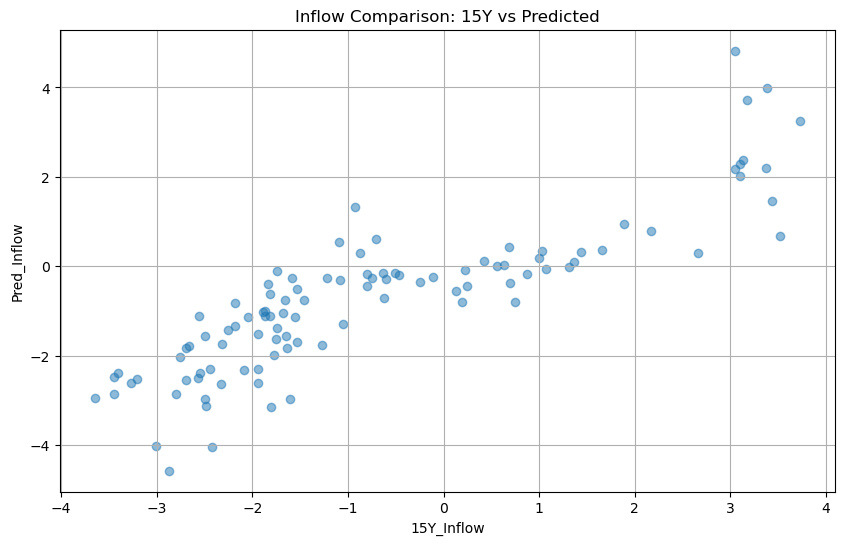

In [116]:
plt.figure(figsize=(10, 6))

#Fill in

plt.xlabel('15Y_Inflow')
plt.ylabel('Pred_Inflow')
plt.title('Inflow Comparison: 15Y vs Predicted')
plt.grid(True)
plt.show()

#### Calculate our temp sensitivity and precip elasticity

In [119]:
temp_s_calc = (model2.coef_[0]/inflow_2000)*100

In [120]:
temp_s_calc

np.float64(-6.276255574146348)

In [121]:
precip_e_calc = (model2.coef_[1]/inflow_2000)*100

In [127]:
(model2.coef_[1]/inflow_2000)*precip_2000

np.float64(1.0176644253592675)